In [4]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import requests
import seaborn as sns

Download data

In [5]:
!pwd

/home/olebi/Projects/Test-Pynapple/notebooks


In [6]:
urls = [
    "https://uni-bonn.sciebo.de/public.php/webdav/NwXtMsrJrjNbQ39",
    "https://uni-bonn.sciebo.de/public.php/webdav/YTgrGyB5MekRP2n",
]
fnames = ["flash_stimuli.parquet", "flash_spikes.parquet"]

print("Downloading Data ...")
for url, fname in zip(urls, fnames):
    response = requests.get(("/").join(url.split("/")[:-1]), auth=(url.split("/")[-1], "ibots"))
    response.raise_for_status()
    with open(fname, "wb") as file:
        file.write(response.content)
print("Done!")

Done!


Load data frames for stimuli and spikes

In [7]:
df_spikes = pd.read_parquet("flash_spikes.parquet")
df_stimuli = pd.read_parquet("flash_stimuli.parquet")

df_spikes.head(), df_stimuli.head()

(     unit_id brain_area   spike_time
 0  951031334         LM  1276.297339
 1  951031154         LM  1276.298206
 2  951031243         LM  1276.298739
 3  951021543         PM  1276.299007
 4  951031253         LM  1276.301272,
     start_time    stop_time
 0  1276.297013  1276.547221
 1  1280.300363  1280.550569
 2  1286.305383  1286.555591
 3  1290.308743  1290.558946
 4  1294.312073  1294.562279)

Extract each unit's spikes from `df_spikes` into a `TsGroup` which contains a `Ts` object for every unit ID.

In [8]:
spikes = nap.TsGroup({
    unit_id: nap.Ts(t=group["spike_time"].to_numpy())
    for unit_id, group in df_spikes.groupby("unit_id")
})
spikes

Index      rate
---------  --------
951015628  0.28331
951015643  0.25295
951015704  0.10455
951015717  2.01689
951015731  0.10118
951015763  1.55482
951015774  1.8921
...        ...
951039413  11.09963
951039454  0.70153
951039462  2.53966
951039560  0.56662
951039854  0.25633
951039863  0.38449
951039870  11.47737

The brain areas of recorded units can be added as metadata. The code below returns a `pandas.Series` where `unit_id` is the index and `brain_area` the values (this assumes each unit is only mapped to one area). The series is then reindexed to match `spikes`.

In [9]:
metadata = (
    df_spikes[["unit_id", "brain_area"]]
    .drop_duplicates()
    .set_index("unit_id")["brain_area"]
    .reindex(spikes.index)
)
metadata

unit_id
951015628    AM
951015643    AM
951015704    AM
951015717    AM
951015731    AM
             ..
951039462    RL
951039560    RL
951039854    RL
951039863    RL
951039870    RL
Name: brain_area, Length: 387, dtype: str

Add the metadata as a `brain_area` column in `spikes`.

In [10]:
spikes.set_info(brain_area=metadata)
spikes

Index      rate      brain_area
---------  --------  ------------
951015628  0.28331   AM
951015643  0.25295   AM
951015704  0.10455   AM
951015717  2.01689   AM
951015731  0.10118   AM
951015763  1.55482   AM
951015774  1.8921    AM
...        ...       ...
951039413  11.09963  RL
951039454  0.70153   RL
951039462  2.53966   RL
951039560  0.56662   RL
951039854  0.25633   RL
951039863  0.38449   RL
951039870  11.47737  RL

Reindex the metadata so `unit_id` becomes a column again and plot every unit's firing rate with a hue to encode brain area.

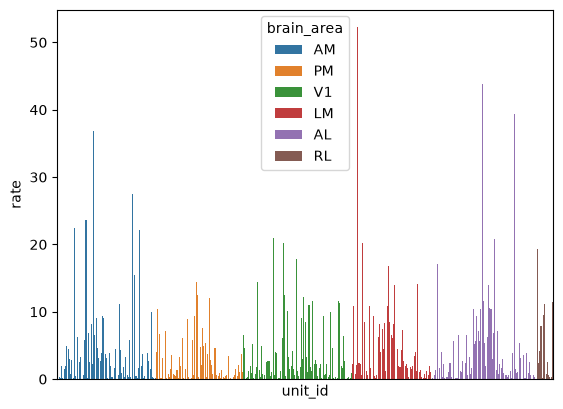

In [11]:
sns.barplot(
    spikes.metadata.reset_index(names="unit_id"),
    x = "unit_id",
    y = "rate",
    hue = "brain_area"
)
plt.xticks([]);

Create an `IntervalSet` to represent stimulus on- and offsets

In [12]:
stim_epochs = nap.IntervalSet(start=df_stimuli.start_time, end=df_stimuli.stop_time)
stim_epochs

index    start               end
0        1276.2970131665072  1276.5472214363754
1        1280.3003631665076  1280.5505689363754
2        1286.3053831665072  1286.5555914363754
3        1290.3087431665076  1290.5589464363752
4        1294.3120731665076  1294.5622789363754
5        1300.3171031665076  1300.5673089363754
6        1304.3204331665072  1304.5706414363754
...      ...                 ...
68       1538.5161231665072  1538.7663314363751
69       1542.5194831665076  1542.7696889363754
70       1546.5228531665073  1546.7730539363752
71       1558.5328631665072  1558.7830689363752
72       1560.5345431665073  1560.7847464363751
73       1570.5428831665076  1570.793091436375
74       1572.5445731665072  1572.7947789363752
shape: (75, 2), time unit: sec.

Compute the PSTH for a single unit

In [13]:
unit_id = 951031253
psth = nap.perievent.compute_perievent(
    spikes[unit_id],
    events=nap.Ts(stim_epochs.start),
    window=(-0.2, 0.8))
psth

Index    rate    events
-------  ------  --------
0        17.0    1280.3
1        14.0    1286.31
2        12.0    1290.31
3        16.0    1294.31
4        17.0    1300.32
5        24.0    1304.32
6        20.0    1308.32
...      ...     ...
67       15.0    1538.52
68       14.0    1542.52
69       17.0    1546.52
70       21.0    1558.53
71       19.0    1560.53
72       25.0    1570.54
73       7.0     1572.54

Create rasterplot

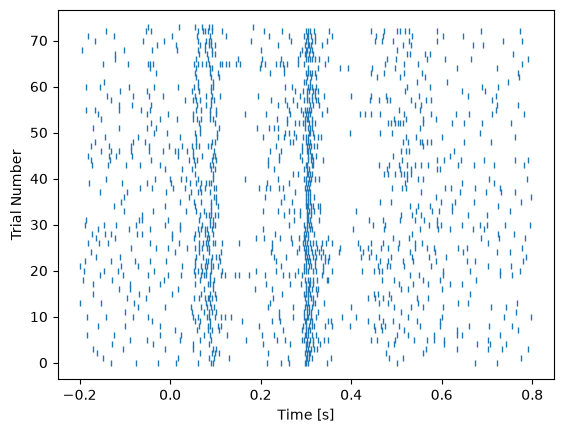

In [14]:
plt.plot(psth.to_tsd(), "|", markersize=5)
plt.xlabel("Time [s]")
plt.ylabel("Trial Number");

Count spikes for every event in 10 ms bins

In [15]:
bin_size = 0.01
psth_rates = psth.count(bin_size) / bin_size
psth_rates

Time (s)    0       1        2        3        4        ...
----------  ------  -------  -------  -------  -------  -----
-0.195      0.0     0.0      0.0      0.0      0.0      ...
-0.185      0.0     0.0      0.0      0.0      0.0      ...
-0.175      0.0     0.0      0.0      0.0      0.0      ...
-0.165      0.0     0.0      100.0    100.0    0.0      ...
-0.155      0.0     0.0      0.0      0.0      0.0      ...
-0.145      0.0     100.0    0.0      0.0      0.0      ...
-0.135      100.0   0.0      0.0      0.0      0.0      ...
...                                                     ...
0.735       0.0     0.0      0.0      100.0    0.0      ...
0.745       0.0     0.0      0.0      0.0      100.0    ...
0.755       0.0     0.0      0.0      0.0      0.0      ...
0.765       0.0     0.0      0.0      0.0      0.0      ...
0.775       0.0     100.0    0.0      0.0      0.0      ...
0.785       0.0     0.0      0.0      0.0      0.0      ...
0.795       0.0     0.0      0.0      

Plot trial-average PSTH

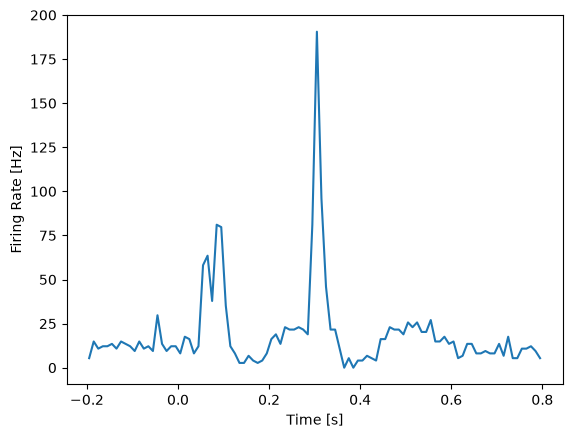

In [16]:
plt.plot(psth_rates.mean(axis=1))
plt.xlabel("Time [s]")
plt.ylabel("Firing Rate [Hz]");

Compute the PSTHs for all units. The result is a dictionary where the keys are unit IDs and the values are the PSTHs.

In [17]:
psths = nap.perievent.compute_perievent(
    spikes,
    events=nap.Ts(stim_epochs.start),
    window=(-0.2, 0.8))
unit_ids = list(psths.keys())
unit_ids[0], psths[unit_ids[0]]

(951015628,
 Index    rate    events
 -------  ------  --------
 0        0.0     1280.3
 1        0.0     1286.31
 2        0.0     1290.31
 3        0.0     1294.31
 4        0.0     1300.32
 5        0.0     1304.32
 6        0.0     1308.32
 ...      ...     ...
 67       0.0     1538.52
 68       0.0     1542.52
 69       0.0     1546.52
 70       0.0     1558.53
 71       0.0     1560.53
 72       0.0     1570.54
 73       0.0     1572.54)

For every PSTH, plot the trial-averaged firing rate in 10 ms bins

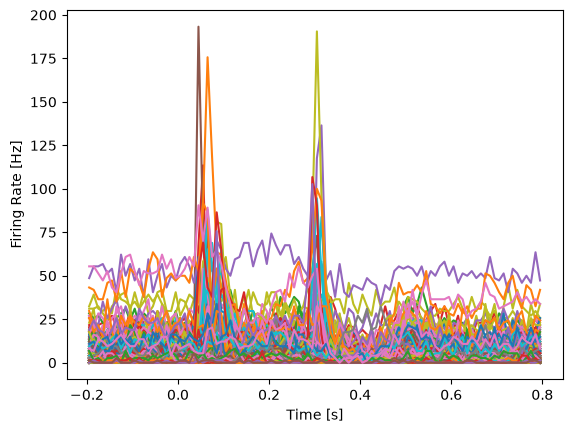

In [18]:
for psth in psths.values():
    spike_counts = psth.count(bin_size)
    mean_rate = spike_counts.mean(axis=1) / bin_size
    plt.plot(mean_rate)

plt.xlabel("Time [s]")
plt.ylabel("Firing Rate [Hz]");

In [27]:
spike_rates = spikes.count(bin_size) / bin_size
spike_rates

Time (s)            951015628    951015643    951015704    951015717    951015731    ...
------------------  -----------  -----------  -----------  -----------  -----------  -----
1276.3023389650293  0.0          0.0          0.0          0.0          0.0          ...
1276.3123389650002  0.0          0.0          0.0          0.0          0.0          ...
1276.3223389650002  0.0          0.0          0.0          0.0          0.0          ...
1276.3323389650002  0.0          0.0          0.0          0.0          0.0          ...
1276.3423389650002  0.0          0.0          0.0          0.0          0.0          ...
1276.3523389650002  0.0          0.0          0.0          0.0          0.0          ...
1276.3623389650002  0.0          0.0          0.0          0.0          0.0          ...
...                                                                                  ...
1572.732338965      0.0          0.0          0.0          0.0          0.0          ...
1572.742338965     

In [29]:
aligned_rates = nap.compute_perievent(
    spike_rates,
    events=nap.Ts(stim_epochs.start),
    window=(-0.2, 0.8),
)
aligned_rates

Time (s)
--------------------  ---------------------
-0.1999999994177415   [[0. ... 0.] ...]
-0.18999999944685442  [[0. ... 0.] ...]
-0.17999999947596734  [[0. ... 0.] ...]
-0.16999999950508027  [[  0. ... 100.] ...]
-0.1599999995341932   [[0. ... 0.] ...]
-0.14999999956330612  [[0. ... 0.] ...]
-0.13999999959241904  [[0. ... 0.] ...]
...
0.7399999978456435    [[0. ... 0.] ...]
0.7499999978165306    [[0. ... 0.] ...]
0.7599999977874177    [[0. ... 0.] ...]
0.7699999977583047    [[0. ... 0.] ...]
0.7799999977291918    [[0. ... 0.] ...]
0.7899999977000789    [[0. ... 0.] ...]
0.799999997670966     [[0. ... 0.] ...]
dtype: float64, shape: (101, 74, 387)

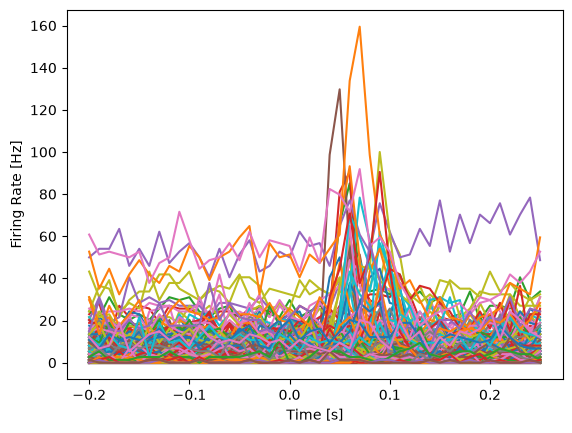

In [31]:
mean_rates = aligned_rates.mean(axis=1)
plt.plot(mean_rates)
plt.xlabel("Time [s]")
plt.ylabel("Firing Rate [Hz]");

Compute the spike count in the baseline interval using the `restrict` method, then plot the baseline-corrected firing rate.

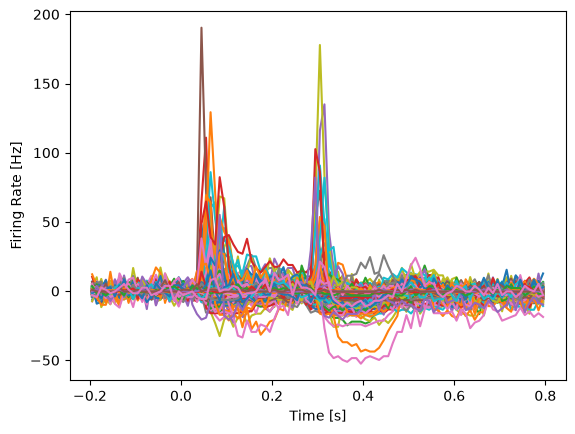

In [19]:
baseline_interval = nap.IntervalSet(start=-0.2, end=0)

for psth in psths.values():
    spike_counts = psth.count(bin_size)
    mean_count = spike_counts.mean(axis=1)
    baseline_count = mean_count.restrict(baseline_interval).mean()
    baseline_corrected_rate = (mean_count - baseline_count) / bin_size
    plt.plot(baseline_corrected_rate)

plt.xlabel("Time [s]")
plt.ylabel("Firing Rate [Hz]");

Do a relative baseline correction to express each PSTH relative to its baseline.

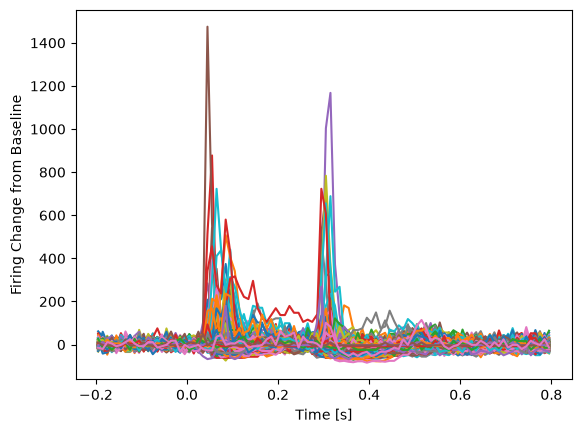

In [20]:
epsilon = 0.1
for psth in psths.values():
    spike_counts = psth.count(bin_size)
    mean_count = spike_counts.mean(axis=1)
    baseline_count = mean_count.restrict(baseline_interval).mean()
    relative_psth = (mean_count - baseline_count) / (baseline_count + epsilon)
    plt.plot(relative_psth / bin_size)

plt.xlabel("Time [s]")
plt.ylabel("Firing Change from Baseline");

Select the units where the change in firing relative to baseline exceeds the threshold.

In [21]:
threshold = 2
psths_responsive = {}

for unit_id, psth in psths.items():
    spike_counts = psth.count(bin_size)
    mean_count = spike_counts.mean(axis=1)
    baseline_count = mean_count.restrict(baseline_interval).mean()
    relative_psth = (mean_count - baseline_count) / (baseline_count + epsilon)

    if len(relative_psth.threshold(threshold)) > 0:
        psths_responsive[unit_id] = psth

len(psths), len(psths_responsive)


(387, 28)

Plot these PSTHs

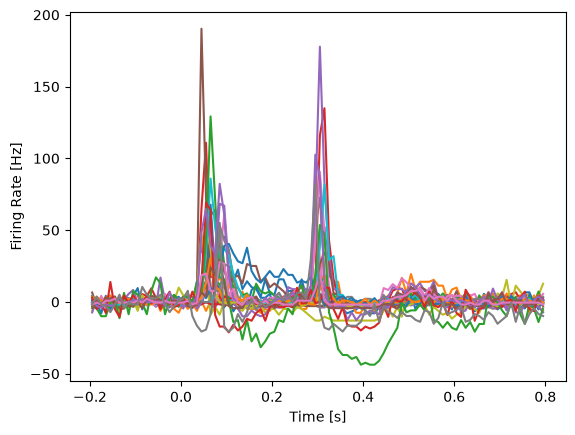

In [22]:
for psth in psths_responsive.values():
    spike_counts = psth.count(bin_size)
    mean_count = spike_counts.mean(axis=1)
    baseline_count = mean_count.restrict(baseline_interval).mean()
    baseline_corrected_rate = (mean_count - baseline_count) / bin_size
    plt.plot(baseline_corrected_rate)

plt.xlabel("Time [s]")
plt.ylabel("Firing Rate [Hz]");

Plot the average PSTH for every brain area. Because the PSTH computed by Pynapple does not presrve the metadata, we have to look it up from `spikes.metdata` and then create a new data frame for the PSTHs that contains the brain area the units are located in.

In [23]:
psth_rows = []

for unit_id, psth in psths.items():
    brain_area = spikes.metadata.loc[unit_id, "brain_area"]

    spike_counts = psth.count(bin_size)
    mean_count = spike_counts.mean(axis=1)

    baseline_count = mean_count.restrict(baseline_interval).mean()
    baseline_corrected_rate = (mean_count - baseline_count) / bin_size

    unit_df = baseline_corrected_rate.as_series().reset_index()
    unit_df.columns = ["time", "firing_rate"]

    unit_df["unit_id"] = unit_id
    unit_df["brain_area"] = brain_area

    psth_rows.append(unit_df)

df_psth = pd.concat(psth_rows, ignore_index=True)
df_psth.head()

,time,firing_rate,unit_id,brain_area
0,-0.195,-0.135135,951015628,AM
1,-0.185,-0.135135,951015628,AM
2,-0.175,-0.135135,951015628,AM
3,-0.165,-0.135135,951015628,AM
4,-0.155,-0.135135,951015628,AM


With the new dataframe, we can easily plot the average PSTH for every brain area using seaborn

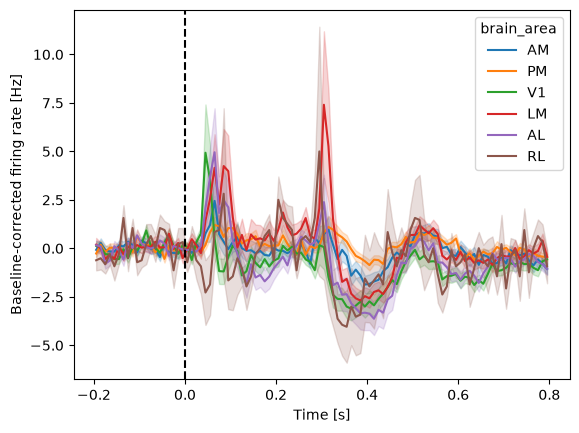

In [24]:
sns.lineplot(
    data=df_psth,
    x="time",
    y="firing_rate",
    hue="brain_area",
    errorbar="se",
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Time [s]")
plt.ylabel("Baseline-corrected firing rate [Hz]");

In [25]:
psths.count(0.01)

AttributeError: 'dict' object has no attribute 'count'